## Let's run intron clustering to annotate alternative splicing events given observed junctions in our cells 

In [5]:
# Load LeafletSC 
import LeafletSC
import os
import pandas as pd 

# Define path that contains some junction files (only 2 files are used for this example, corresponding to 2 individual cells)
juncs_path = "/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH"
print("The junctions are loaded from the following path: " + juncs_path) 

# print the files in the path 
print("The files in the path are: " + str(os.listdir(juncs_path)))

# define path for saving the output data 
output_path = "/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/"

The junctions are loaded from the following path: /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH
The files in the path are: ['Choroid_plexus_epithelial_cells_APOE4_female.juncswbarcodes', 'Pituitary_cells_5xFAD_male.juncswbarcodes', 'Hindbrain_neurons_1_6mo_male.barcodes', 'Interneurons_2_5xFAD_male.juncswbarcodes', 'Hindbrain_neurons_1_5xFAD_female.juncswbarcodes', 'Cerebellum_interneurons_6mo_female.juncs', 'Striatal_neurons_2_6mo_female.juncswbarcodes', 'Striatal_neurons_1_6mo_male.juncswbarcodes', 'Cerebellum_interneurons_21mo_male.juncswbarcodes', 'Ependymal_cells_5xFAD_female.juncs', 'Hindbrain_neurons_2_APOE4_female.juncs', 'Striatal_neurons_1_21mo_male.barcodes', 'Hindbrain_neurons_2_APOE4_female.juncswbarcodes', 'Vascular_leptomeningeal_cells_APOE4_female.barcodes', 'Cortical_projection_neurons_3_21mo_female.juncswbarcodes', 'Interbrain_and_midbrain_neurons_1_21mo_male.barcodes', 'OB_neurons_3_APOE4_female.barcodes', 'Inferior_olivary_nucleus_n

### Let's first define some parameters for the analysis

In [6]:
from LeafletSC.clustering.find_intron_clusters import main as find_intron_clusters
from LeafletSC.clustering.prepare_model_input import main as prep_model_input
from LeafletSC.clustering.find_intron_clusters import visualize_local_events

# junc_files defines a path for where junction files can be found, in this case, the path is defined above
junc_files = juncs_path

# we provide a gtf file for the human genome as well to make better sense of the junctions that are detected in cells
# please replace with the path to the gtf file on your system
gtf_file="/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/genome_files/gencode.vM27.basic.annotation.gtf" 

# define additional parameters 
sequencing_type = "single_cell"

# ensure output files are to be saved in output_path 
output_file = output_path + "test_intron_clusters_RH"
junc_bed_file= output_path + "test_juncs_RH.bed" # you can load this file into IGV to visualize the junction coordinates 
min_intron_length = 50
max_intron_length = 500000
threshold_inc = 0.01 
min_junc_reads = 2
min_num_cells_wjunc = 2
keep_singletons = False # ignore junctions that do not share splice sites with any other junction (likely const)
junc_suffix = "*.juncswbarcodes" # depends on how you ran regtools 

### Run intron clustering 

In [7]:
all_juncs_df = find_intron_clusters(junc_files=junc_files, gtf_file=gtf_file, output_file=output_file, 
                       sequencing_type=sequencing_type, junc_bed_file=junc_bed_file, 
                       threshold_inc=threshold_inc, min_intron = min_intron_length,
                       max_intron=max_intron_length, min_junc_reads=min_junc_reads,
                       singleton=keep_singletons,
                       junc_suffix=junc_suffix, min_num_cells_wjunc=min_num_cells_wjunc,
                       run_notebook = True)

Loading files obtained from single_cell sequencing


100%|██████████| 1/1 [01:30<00:00, 90.21s/it]


The total number of files that could not be read is 1 as these had no junctions
The gtf file you provided is /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/genome_files/gencode.vM27.basic.annotation.gtf
Reading the gtf may take a minute...


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'level', 'mgi_id', 'havana_gene', 'transcript_id', 'transcript_type', 'transcript_name', 'transcript_support_level', 'tag', 'havana_transcript', 'exon_number', 'exon_id', 'protein_id', 'ccdsid', 'ont']


Reading gtf file took 93.01 seconds
The number of unique exons is 323028
The number of unique transcript ids is 80576
The number of unique gene ids is 55358
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
Done extracting exons from gtf file
Cleaning up 'chrom' column
Making gr object from all junctions across all cell types
The number of junctions prior to assessing distance to exons is 210720
Annotating junctions with known exons based on input gtf file
The number of junctions after assessing distance to exons is 166370
Clustering intron splicing events by gene_id
The number of clusters after clustering by gene_id is 143521
The number of junctions after removing singletons is 166369
The number of clusters after removing singletons is 143520
The number of clusters after filtering for shared splice sites is 10191
The number of junctions after filtering for shared splice sites is 33024
Refining intron clusters to account for junction usage ratio threshold...
Done refining cluster

In [34]:
print(junc_bed_file)

/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/test_juncs_RH.bed


In [8]:
# load bed file 
juncs_bed = pd.read_csv(junc_bed_file, sep="\t", header=None)
# remove columns 3 and 4 
juncs_bed = juncs_bed.drop(columns=[3, 4])
juncs_bed.columns = ["Chromosome", "Start", "End", "Strand", "junction_id", "Start_b", "End_b", "gene_id", "gene_name", "transcript_id", "exon_id"]

# cmobine with all_juncs_df and prep df for visualization 
dat_vis = all_juncs_df[["chrom", "chromStart", "chromEnd", "strand", "intron_length", "counts_total", "junction_id", "Cluster"]]
dat_vis = dat_vis.drop_duplicates()
# merge dat_vis with juncs_bed using all common columns 
dat_vis = dat_vis.merge(juncs_bed, how="left", on=["junction_id"])

In [9]:
dat_vis

,chrom,chromStart,chromEnd,strand,intron_length,counts_total,junction_id,Cluster,Chromosome,Start,End,Strand,Start_b,End_b,gene_id,gene_name,transcript_id,exon_id
0,10,100352165,100353638,+,1473,182,10_100352165_100353638,6727,10,100352165,100353638,+,100352015,100352165,ENSMUSG00000019971.11,Cep290,ENSMUST00000220346.2,ENSMUSE00001001531.2
1,10,100352165,100354315,+,2150,3,10_100352165_100354315,6727,10,100352165,100354315,+,100352015,100352165,ENSMUSG00000019971.11,Cep290,ENSMUST00000220346.2,ENSMUSE00001001531.2
2,10,100353754,100354315,+,561,209,10_100353754_100354315,6727,10,100353754,100354315,+,100353638,100353754,ENSMUSG00000019971.11,Cep290,ENSMUST00000220346.2,ENSMUSE00001084988.2
3,10,101847705,102186795,+,339090,40,10_101847705_102186795,6706,10,101847705,102186795,+,101847593,101847705,ENSMUSG00000019888.17,Mgat4c,ENSMUST00000179929.8,ENSMUSE00000845828.2
4,10,101994920,102186795,+,191875,10,10_101994920_102186795,6706,10,101994920,102186795,+,101994718,101994920,ENSMUSG00000019888.17,Mgat4c,ENSMUST00000163753.8,ENSMUSE00000744776.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28557,Y,1245219,1245406,-,187,25,Y_1245219_1245406,11898,Y,1245219,1245406,-,1245155,1245219,ENSMUSG00000068457.15,Uty,ENSMUST00000143286.8,ENSMUSE00001288509.2
28558,Y,90797248,90804564,+,7316,132,Y_90797248_90804564,11894,Y,90797248,90804564,+,90796858,90797248,ENSMUSG00000096768.9,Gm47283,ENSMUST00000179483.9,ENSMUSE00001002838.2
28559,Y,90797248,90804593,+,7345,4,Y_90797248_90804593,11894,Y,90797248,90804593,+,90796858,90797248,ENSMUSG00000096768.9,Gm47283,ENSMUST00000179483.9,ENSMUSE00001002838.2
28560,Y,90804686,90827617,+,22931,708,Y_90804686_90827617,11895,Y,90804686,90827617,+,90804564,90804686,ENSMUSG00000096768.9,Gm47283,ENSMUST00000179483.9,ENSMUSE00001269726.2


     chrom  chromStart_kb  chromEnd_kb strand  intron_length  counts_total  \
4725    13      25038.538    25040.634      +           2096            97   
4726    13      25038.538    25046.620      +           8082             3   
4727    13      25041.410    25041.903      +            493           342   
4728    13      25042.093    25046.620      +           4527           290   

        Start_b      End_b               exon_id  
4725  25038.392  25038.538  ENSMUSE00000251843.4  
4726  25038.392  25038.538  ENSMUSE00000251843.4  
4727  25040.634  25041.410  ENSMUSE00000251832.2  
4728  25041.903  25042.093  ENSMUSE00000251824.2  
The junction of interest is 13_25042093_25046620


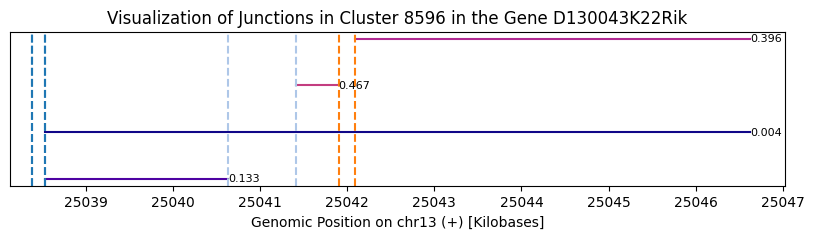

In [10]:
#from LeafletSC.clustering.find_intron_clusters import visualize_junctions
junc_id = all_juncs_df.junction_id.sample(1).values[0]
j = junc_id
visualize_local_events(dat_vis, j, p_usage_ratio=True)

### Now let's convert the intron clusters to a format that can be used by LeafletSC

In [11]:
intron_clusters = "/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/test_intron_clusters_RH_50_500000_2_20240425_single_cell.gz" # path to the intron clusters file
output_file = output_path + "test_model_input_RH" # name of the output file
has_genes = "yes" # since we used a gtf file to obtain the intron clusters, we can set this to yes
chunk_size = 5000 # number of junctions to process at a time from the intron clusters files
metadata = None # can replace with path, if metadata is available for cells (cell type, origin, library ID...)

In [12]:
prep_model_input(intron_clusters, output_file, has_genes, chunk_size, metadata)

The intron clusters file you provided is /gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/test_intron_clusters_RH_50_500000_2_20240425_single_cell.gz, reading in chunks of 5000 lines
Processing intron clusters


265it [00:34,  7.77it/s]


Done processing intron clusters
The number of intron clusters evaluated is 9187
The number of junctions evaluated is 28562
The number of cells evaluated is 504917
The number of clusters with only one junction is 0
A gtf file was used to generate intron clusters
The number of total cells evaluated is 504917
The number of cells per cell type is:
cell_type
/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH/Astrocytes_21mo_female.juncswbarcodes                        4088
/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH/Astrocytes_21mo_male.juncswbarcodes                          3751
/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH/Astrocytes_3mo_female.juncswbarcodes                         5724
/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/junctions/RH/Astrocytes_3mo_male.juncswbarcodes                           6237
/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/L

### Take a quick look at the input file that will go into the model to get familiarized with all the columns

In [13]:
model_input_data = "/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/test_model_input_RH.h5"
summarized_data = pd.read_hdf(model_input_data, 'df')
print(summarized_data.head())

                                             cell_id  Cluster  Cluster_Counts  \
0  EasySci_001.AACCGATTGCAATTATCAGC_/gpfs/commons...      312               1   
1  EasySci_001.AACCGATTGCAATTATCAGC_/gpfs/commons...      332               1   
2  EasySci_001.AACCGATTGCAATTATCAGC_/gpfs/commons...      404               1   
3  EasySci_001.AACCGATTGCAATTATCAGC_/gpfs/commons...     1225               1   
4  EasySci_001.AACCGATTGCAATTATCAGC_/gpfs/commons...     1741               1   

             junction_id                gene_id  junc_count  \
0    1_66507697_66508622  ENSMUSG00000055567.19           1   
1  1_128118476_128121196  ENSMUSG00000056211.14           1   
2  1_154348459_154349602  ENSMUSG00000004110.18           1   
3    2_14619167_14879580  ENSMUSG00000057914.16           1   
4  2_140503671_140505180  ENSMUSG00000051379.13           1   

                                           cell_type  junc_ratio  \
0  /gpfs/commons/projects/knowles_singlecell_spli...         1.0  

#### Note that fow now, the values in cell_type default to the cell's path, in the future it will be possible to specify the cell type in the metadata file

In [14]:
# let's see all the columns in the summarized data
print(summarized_data.columns)

Index(['cell_id', 'Cluster', 'Cluster_Counts', 'junction_id', 'gene_id',
       'junc_count', 'cell_type', 'junc_ratio', 'cell_id_index',
       'junction_id_index'],
      dtype='object')


#### We can quickly visualize the overall junction usage ratio distribution across all cells

In [15]:
summarized_data.head()

,cell_id,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,cell_type,junc_ratio,cell_id_index,junction_id_index
0,EasySci_001.AACCGATTGCAATTATCAGC_/gpfs/commons...,312,1,1_66507697_66508622,ENSMUSG00000055567.19,1,/gpfs/commons/projects/knowles_singlecell_spli...,1.0,0,13062
1,EasySci_001.AACCGATTGCAATTATCAGC_/gpfs/commons...,332,1,1_128118476_128121196,ENSMUSG00000056211.14,1,/gpfs/commons/projects/knowles_singlecell_spli...,1.0,0,11812
2,EasySci_001.AACCGATTGCAATTATCAGC_/gpfs/commons...,404,1,1_154348459_154349602,ENSMUSG00000004110.18,1,/gpfs/commons/projects/knowles_singlecell_spli...,1.0,0,12119
3,EasySci_001.AACCGATTGCAATTATCAGC_/gpfs/commons...,1225,1,2_14619167_14879580,ENSMUSG00000057914.16,1,/gpfs/commons/projects/knowles_singlecell_spli...,1.0,0,14113
4,EasySci_001.AACCGATTGCAATTATCAGC_/gpfs/commons...,1741,1,2_140503671_140505180,ENSMUSG00000051379.13,1,/gpfs/commons/projects/knowles_singlecell_spli...,1.0,0,14067


In [16]:
print(len(summarized_data.cell_id.unique()))

504917


In [17]:
all_cell_ids = summarized_data.cell_id

# clean up each cell_id using .str.split("_/gpfs")[0]
all_cell_ids_clean = [x.split("_/gpfs")[0] for x in all_cell_ids]
summarized_data["cell_id_clean"] = all_cell_ids_clean

In [18]:
cell_types = summarized_data.cell_type
cell_types[0]
# keep everything after Leaflet/junctions/RH/ and before .juncswbarcodes
cell_types_clean = [x.split("Leaflet/junctions/RH/")[1].split(".juncswbarcodes")[0] for x in cell_types]
summarized_data["cell_type_clean"] = cell_types_clean

# remove old cell_type column 
summarized_data = summarized_data.drop(columns=["cell_type"])

In [19]:
# turn summarized counts into dataframe 
summarized_data_df = pd.DataFrame(summarized_data.cell_type_clean.value_counts()).reset_index()
summarized_data_df.columns = ["sample", "cell_junction_pairs"]
summarized_data_df = summarized_data_df.sort_values(by="cell_junction_pairs", ascending=False)

# add column mouse sex is everything after last "_" in sample column
summarized_data_df["sex"] = summarized_data_df["sample"].str.split("_").str[-1]
# add column mouse state is everything after second last "_" in sample column
summarized_data_df["state"] = summarized_data_df["sample"].str.split("_").str[-2]
# add cell type is everything before second last "_" in sample 
summarized_data_df["cell_type"] = summarized_data_df["sample"].str.split("_").str[:-2].str.join("_")

In [20]:
len(summarized_data_df.cell_type.unique())

30

In [21]:
print(summarized_data_df.state.unique())

['6mo' '5xFAD' '21mo' 'APOE4' '3mo']


Text(0.5, 1.0, 'Number of cell junction pairs per cell type')

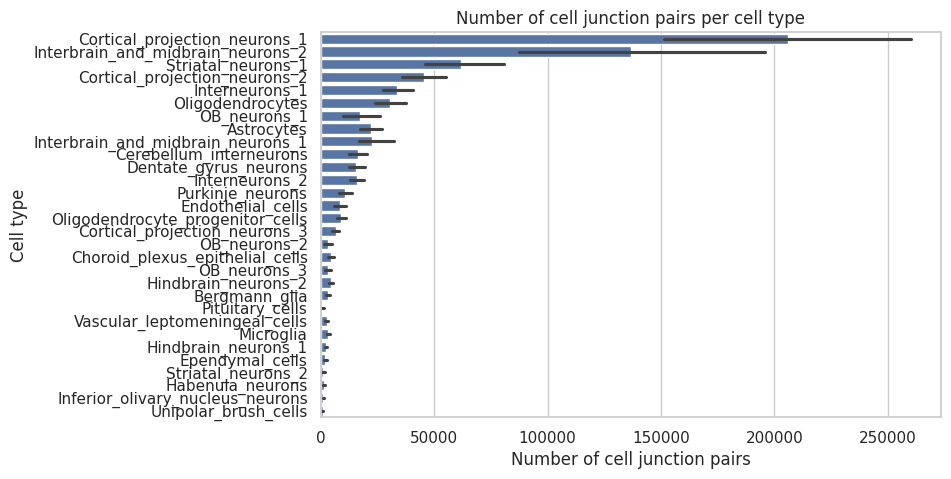

In [22]:
# make barplot of summarized_data_df 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# sort summarized_data_df by cell_junction_pairs
summarized_data_df = summarized_data_df.sort_values(by="cell_junction_pairs", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="cell_junction_pairs", y="cell_type", data=summarized_data_df) 
# xlab add 
plt.xlabel("Number of cell junction pairs")
plt.ylabel("Cell type")
plt.title("Number of cell junction pairs per cell type")

Text(0.5, 1.0, 'Number of cell junction pairs per mouse type/sex')

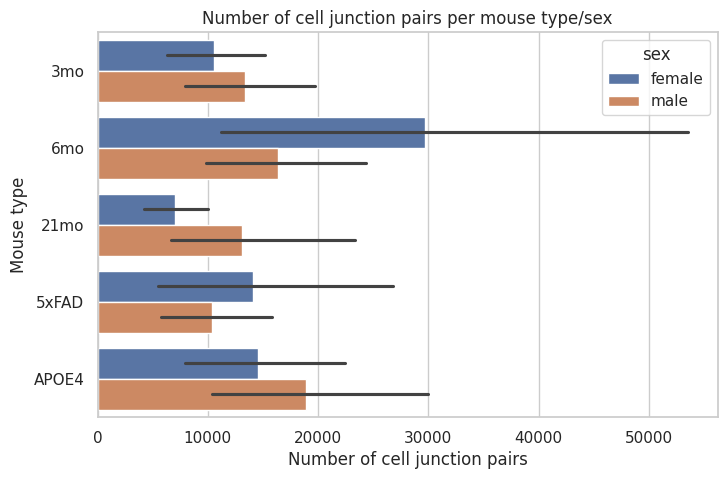

In [23]:
# Make the same plot but now per mouse type and sex 

# reorder state column values so that it's 3mo, 6mo, 21mo 5xFAD, 21mo WT
summarized_data_df["state"] = pd.Categorical(summarized_data_df["state"], ["3mo", "6mo", "21mo", "5xFAD", "APOE4"])

plt.figure(figsize=(8, 5))
sns.barplot(x="cell_junction_pairs", y="state", hue="sex", data=summarized_data_df)
# xlab add
plt.xlabel("Number of cell junction pairs")
plt.ylabel("Mouse type")
plt.title("Number of cell junction pairs per mouse type/sex") 

In [24]:
# rename cell_type column to sample
summarized_data = summarized_data.rename(columns={"cell_type_clean": "sample"})
# merge with sumamrized_datA_df
summarized_data = summarized_data.merge(summarized_data_df, how="left", on="sample")
summarized_data.head()

,cell_id,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,junc_ratio,cell_id_index,junction_id_index,cell_id_clean,sample,cell_junction_pairs,sex,state,cell_type
0,EasySci_001.AACCGATTGCAATTATCAGC_/gpfs/commons...,312,1,1_66507697_66508622,ENSMUSG00000055567.19,1,1.0,0,13062,EasySci_001.AACCGATTGCAATTATCAGC,Striatal_neurons_1_APOE4_male,117728,male,APOE4,Striatal_neurons_1
1,EasySci_001.AACCGATTGCAATTATCAGC_/gpfs/commons...,332,1,1_128118476_128121196,ENSMUSG00000056211.14,1,1.0,0,11812,EasySci_001.AACCGATTGCAATTATCAGC,Striatal_neurons_1_APOE4_male,117728,male,APOE4,Striatal_neurons_1
2,EasySci_001.AACCGATTGCAATTATCAGC_/gpfs/commons...,404,1,1_154348459_154349602,ENSMUSG00000004110.18,1,1.0,0,12119,EasySci_001.AACCGATTGCAATTATCAGC,Striatal_neurons_1_APOE4_male,117728,male,APOE4,Striatal_neurons_1
3,EasySci_001.AACCGATTGCAATTATCAGC_/gpfs/commons...,1225,1,2_14619167_14879580,ENSMUSG00000057914.16,1,1.0,0,14113,EasySci_001.AACCGATTGCAATTATCAGC,Striatal_neurons_1_APOE4_male,117728,male,APOE4,Striatal_neurons_1
4,EasySci_001.AACCGATTGCAATTATCAGC_/gpfs/commons...,1741,1,2_140503671_140505180,ENSMUSG00000051379.13,1,1.0,0,14067,EasySci_001.AACCGATTGCAATTATCAGC,Striatal_neurons_1_APOE4_male,117728,male,APOE4,Striatal_neurons_1


In [25]:
# Get number of cell_id_clean unique per mouse state and cell_type 
cells_summ = summarized_data.groupby(["state", "cell_type"])["cell_id_clean"].nunique().reset_index()
# sort by cell_id_clean and make barplot 
cells_summ = cells_summ.sort_values(by="cell_id_clean", ascending=False)


/scratch/ipykernel_27541/2516087553.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cells_summ = summarized_data.groupby(["state", "cell_type"])["cell_id_clean"].nunique().reset_index()


<Axes: xlabel='cell_id_clean', ylabel='cell_type'>

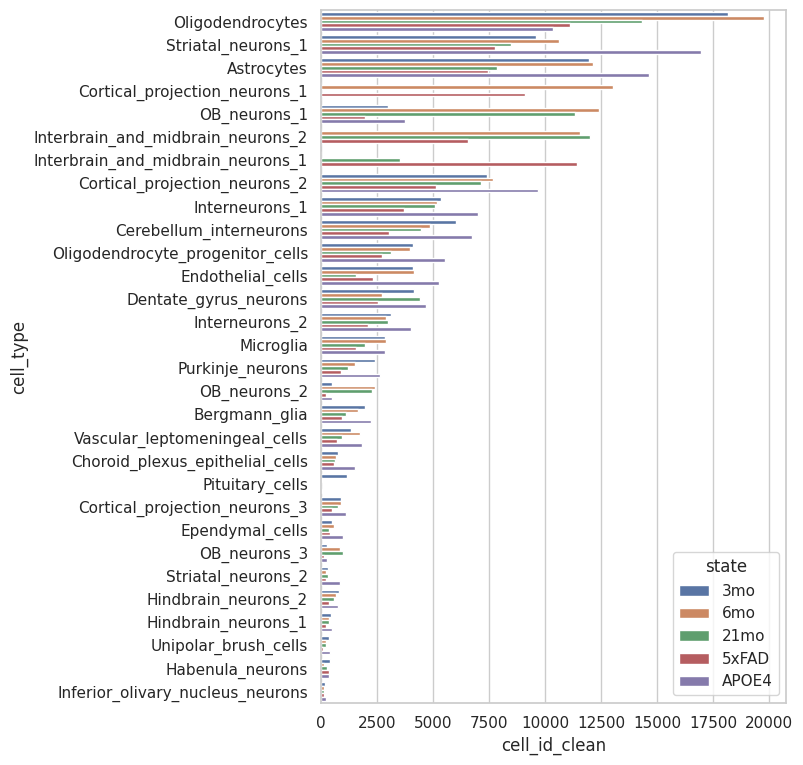

In [26]:
plt.figure(figsize=(6, 9))
sns.barplot(x="cell_id_clean", y="cell_type", hue="state", data=cells_summ)

In [27]:
# remove cell_id column and rename cell_id_clean to cell_id 
summarized_data = summarized_data.drop(columns=["cell_id"])
summarized_data = summarized_data.rename(columns={"cell_id_clean": "cell_id"})

summarized_data.cell_type.unique()

array(['Striatal_neurons_1', 'Ependymal_cells',
       'Oligodendrocyte_progenitor_cells', 'OB_neurons_1',
       'Oligodendrocytes', 'Purkinje_neurons', 'Interneurons_2',
       'Interneurons_1', 'Hindbrain_neurons_2', 'Dentate_gyrus_neurons',
       'Cerebellum_interneurons', 'Interbrain_and_midbrain_neurons_2',
       'Interbrain_and_midbrain_neurons_1',
       'Cortical_projection_neurons_2', 'Habenula_neurons',
       'Endothelial_cells', 'Astrocytes', 'Microglia',
       'Cortical_projection_neurons_1', 'Choroid_plexus_epithelial_cells',
       'Bergmann_glia', 'Inferior_olivary_nucleus_neurons',
       'Pituitary_cells', 'OB_neurons_2', 'Vascular_leptomeningeal_cells',
       'Striatal_neurons_2', 'Cortical_projection_neurons_3',
       'Hindbrain_neurons_1', 'OB_neurons_3', 'Unipolar_brush_cells'],
      dtype=object)

In [28]:
print(model_input_data)

/gpfs/commons/projects/knowles_singlecell_splicing/EasySci/Leaflet/test_model_input_RH.h5


In [33]:
# calculate number of junctions detected in each cell 
junctions_per_cell = summarized_data.groupby("cell_id")["junction_id"].nunique().reset_index()
junctions_per_cell

,cell_id,junction_id
0,EasySci_001.AACCGATTGCAATTATCAGC,26
1,EasySci_001.AACCGATTGCATAGTCGTAG,3
2,EasySci_001.AACCGATTGCCGCCTCGAAC,2
3,EasySci_001.AACCGATTGCGTCCTAGAGG,4
4,EasySci_001.AACCGATTGCTTAGGACCGG,3
...,...,...
504912,EasySci_192.TTGGTTCTCAAAGTTGCCAT,2
504913,EasySci_192.TTGGTTCTCACCGCTATATT,2
504914,EasySci_192.TTGGTTCTCACTGGATTAGT,9
504915,EasySci_192.TTGGTTCTCACTTGATTGCC,3


In [ ]:
# rewrite the summarized data to a new file h5 format 
summarized_data.to_hdf(model_input_data, key='df', mode='w', complevel=9, complib='zlib', format="table")  

### Now we have everything need to run the Leaflet mixture model! Please refer to the next notebook for the next steps.